In [2]:
import numpy as np
import matplotlib.pyplot as plt
from Analysis import (
    SpatiotemporalAnalysis,demodulate
)
from matplotlib.lines import Line2D

Fogi timing

In [3]:
ctrl_path = "data/"

result_dict_tx = dict(
    data_ph0 = dict(target_freq=9.38, date="2025-08-12", acquire_time="124754", duration=1000),
    data_ph1 = dict(target_freq=9.38, date="2025-08-12", acquire_time="124137", duration=1000),
    data_ph2 = dict(target_freq=9.38, date="2025-08-12", acquire_time="124227", duration=1000),
    data_ph3 = dict(target_freq=9.38, date="2025-08-12", acquire_time="125025", duration=1000),
)

result_dict_rx = dict(
    data_ph0 = dict(target_freq=9.38, date="2025-08-12", acquire_time="110853", duration=1000),
    data_ph1 = dict(target_freq=9.38, date="2025-08-12", acquire_time="110223", duration=1000),
    data_ph2 = dict(target_freq=9.38, date="2025-08-12", acquire_time="110313", duration=1000),
    data_ph3 = dict(target_freq=9.38, date="2025-08-12", acquire_time="110403", duration=1000),
)

Fit curve at x=18.000 -> y=0.989
ideal efficiency 0.989179256003079
delay 22.500000000000004
Fit curve at x=18.000 -> y=0.981
Fit curve at x=18.000 -> y=0.002
ideal efficiency 0.0022815504951683367
delay 27.000000000000007
Fit curve at x=18.000 -> y=0.045
Fit curve at x=18.000 -> y=0.004
ideal efficiency 0.0037626067503813377
delay 35.099999999999994
Fit curve at x=18.000 -> y=0.003
Fit curve at x=18.000 -> y=0.000
ideal efficiency 4.6398366735449895e-05
delay 36.89999999999999
Fit curve at x=18.000 -> y=0.000


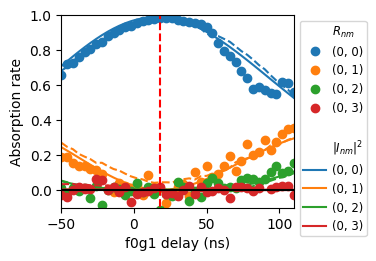

In [5]:
header ="data/"
ph0_fo0 = "/2025-08-13/2025-08-13T081809_9c21d1b7-j1_JPA_comm_timing"
ph0_fo1 = "/2025-08-12/2025-08-12T145332_addb4dad-j1_JPA_comm_timing"
ph0_fo2 = "/2025-08-12/2025-08-12T223011_78afd813-j1_JPA_comm_timing"
ph0_fo3 = "/2025-08-12/2025-08-12T162316_371a7ee5-j1_JPA_comm_timing"

num_of_ph_amp = 1
num_of_fogi_timing = 51
f_if = (9.5-9.38)*1e9

acquisition_00 = SpatiotemporalAnalysis(ctrl_path, ph0_fo0, ctrl_path, result_dict_tx['data_ph0'], result_dict_rx['data_ph0'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_01 = SpatiotemporalAnalysis(ctrl_path, ph0_fo1, ctrl_path, result_dict_tx['data_ph0'], result_dict_rx['data_ph1'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_02 = SpatiotemporalAnalysis(ctrl_path, ph0_fo2, ctrl_path, result_dict_tx['data_ph0'], result_dict_rx['data_ph2'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_03 = SpatiotemporalAnalysis(ctrl_path, ph0_fo3, ctrl_path, result_dict_tx['data_ph0'], result_dict_rx['data_ph3'], num_of_ph_amp, num_of_fogi_timing, f_if)

fig, ax = plt.subplots(1, 1, figsize=(3, 2.5))
acquisition_00.plot_results(ax, label="ph_0 & fogi_0", color="tab:blue", fitting=True, init_fit=True, x_target=18, eight=False)
acquisition_01.plot_results(ax, label="ph_0 & fogi_1", color="tab:orange", fitting=True, init_fit=True, x_target=18, eight=False)
acquisition_02.plot_results(ax, label="ph_0 & fogi_2", color="tab:green", fitting=True, init_fit=True, x_target=18, eight=False)
acquisition_03.plot_results(ax, label="ph_0 & fogi_3", color="tab:red", fitting=True, init_fit=True, x_target=18, eight=False)

ax.set_ylim(-0.10, 1)
ax.set_xlim(-50, 110)
ax.vlines(18, -10, 100, color="r", linestyle="dashed")
custom_legend = [
    Line2D([0], [0], color="none", marker="o", linestyle="None", label="$R_{nm}$"),
    Line2D([0], [0], color="tab:blue", marker="o", linestyle="None",label="(0, 0)"),
    Line2D([0], [0], color="tab:orange", marker="o", linestyle="None",label="(0, 1)"),
    Line2D([0], [0], color="tab:green", marker="o", linestyle="None",label="(0, 2)"),
    Line2D([0], [0], color="tab:red", marker="o", linestyle="None",label="(0, 3)"),
    Line2D([0], [0], color="none", marker="", label=""),
    Line2D([0], [0], color="none", linestyle="-", label="$|I_{nm}|^2$"),
    Line2D([0], [0], color="tab:blue", linestyle="-", label="(0, 0)"),
    Line2D([0], [0], color="tab:orange", linestyle="-", label="(0, 1)"),
    Line2D([0], [0], color="tab:green", linestyle="-", label="(0, 2)"),
    Line2D([0], [0], color="tab:red", linestyle="-", label="(0, 3)"),
]
plt.legend(handles=custom_legend, loc="upper left", bbox_to_anchor=(1., 1),ncol=1,  fontsize="small", 
           handletextpad=0.5, borderpad=0.3 )
plt.hlines(0, -50, 110, "black")
plt.xlabel("f0g1 delay (ns)")
plt.ylabel("Absorption rate")
plt.show()

In [6]:
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.

photon 1

Fit curve at x=18.000 -> y=0.002
ideal efficiency 0.001619478403331584
delay 26.1
Fit curve at x=18.000 -> y=0.011
Fit curve at x=18.000 -> y=0.983
ideal efficiency 0.9834119660128764
delay 19.800000000000004
Fit curve at x=18.000 -> y=0.892
Fit curve at x=18.000 -> y=0.006
ideal efficiency 0.006253889845570505
delay 27.000000000000007
Fit curve at x=18.000 -> y=0.012
Fit curve at x=18.000 -> y=0.001
ideal efficiency 0.0009710511217394889
delay 30.6
Fit curve at x=18.000 -> y=0.003


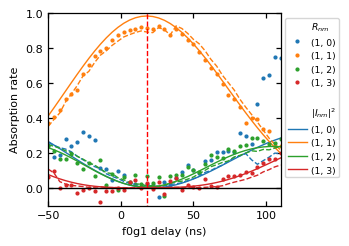

In [7]:
ph1_fo0 = "/2025-08-12/2025-08-12T205345_fff72f75-j1_JPA_comm_timing"
ph1_fo1 = "/2025-08-12/2025-08-12T214421_11bce74b-j1_JPA_comm_timing"
ph1_fo2 = "/2025-08-12/2025-08-12T183812_10814b2f-j1_JPA_comm_timing"
ph1_fo3 = "/2025-08-12/2025-08-12T192312_59d17cb7-j1_JPA_comm_timing"

acquisition_10 = SpatiotemporalAnalysis(ctrl_path, ph1_fo0, ctrl_path, result_dict_tx['data_ph1'], result_dict_rx['data_ph0'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_11 = SpatiotemporalAnalysis(ctrl_path, ph1_fo1, ctrl_path, result_dict_tx['data_ph1'], result_dict_rx['data_ph1'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_12 = SpatiotemporalAnalysis(ctrl_path, ph1_fo2, ctrl_path, result_dict_tx['data_ph1'], result_dict_rx['data_ph2'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_13 = SpatiotemporalAnalysis(ctrl_path, ph1_fo3, ctrl_path, result_dict_tx['data_ph1'], result_dict_rx['data_ph3'], num_of_ph_amp, num_of_fogi_timing, f_if)

fig, ax = plt.subplots(1, 1, figsize=(3, 2.5))
acquisition_10.plot_results(ax, label="ph_1 & fogi_0", color="tab:blue", fitting=True, init_fit=True, x_target=18)
acquisition_11.plot_results(ax, label="ph_1 & fogi_1", color="tab:orange", fitting=True, init_fit=True, x_target=18)
acquisition_12.plot_results(ax, label="ph_1 & fogi_2", color="tab:green", fitting=True, init_fit=True, x_target=18)
acquisition_13.plot_results(ax, label="ph_1 & fogi_3", color="tab:red", fitting=True, init_fit=True, x_target=18)

ax.set_ylim(-0.1, 1)
ax.set_xlim(-50, 110)
plt.vlines(18, -10, 100, linestyles='--',colors='red')
custom_legend = [
    Line2D([0], [0], color="none", marker="o", linestyle="None", label="$R_{nm}$"), 
    Line2D([0], [0], color="tab:blue", marker="o", linestyle="None",label="(1, 0)"),
    Line2D([0], [0], color="tab:orange", marker="o", linestyle="None",label="(1, 1)"),
    Line2D([0], [0], color="tab:green", marker="o", linestyle="None",label="(1, 2)"),
    Line2D([0], [0], color="tab:red", marker="o", linestyle="None",label="(1, 3)"),
    Line2D([0], [0], color="none", marker="", label=""),
    Line2D([0], [0], color="none", linestyle="-", label="$|I_{nm}|^2$"), 
    Line2D([0], [0], color="tab:blue", linestyle="-", label="(1, 0)"),
    Line2D([0], [0], color="tab:orange", linestyle="-", label="(1, 1)"),
    Line2D([0], [0], color="tab:green", linestyle="-", label="(1, 2)"),
    Line2D([0], [0], color="tab:red", linestyle="-", label="(1, 3)"),
]
plt.legend(handles=custom_legend, loc="upper left", bbox_to_anchor=(1., 1),ncol=1,  fontsize="small", 
           handletextpad=0.5, borderpad=0.3 )
plt.hlines(0, -50, 110, "black")
plt.xlabel("f0g1 delay (ns)")
plt.ylabel("Absorption rate")
plt.show()

photon 2

Fit curve at x=18.000 -> y=0.002
ideal efficiency 0.0022300315155825193
delay 79.19999999999999
Fit curve at x=18.000 -> y=0.001
Fit curve at x=18.000 -> y=0.005
ideal efficiency 0.004613736941994272
delay 25.200000000000003
Fit curve at x=18.000 -> y=0.003
Fit curve at x=18.000 -> y=0.966
ideal efficiency 0.9658198365710874
delay 21.6
Fit curve at x=18.000 -> y=0.991
Fit curve at x=18.000 -> y=0.007
ideal efficiency 0.007444517365445264
delay 31.5
Fit curve at x=18.000 -> y=0.006


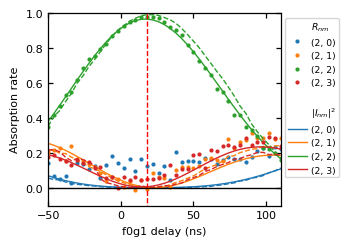

In [8]:
ph2_fo0 = "/2025-08-12/2025-08-12T200813_a3f91ff0-j1_JPA_comm_timing"
ph2_fo1 = "/2025-08-13/2025-08-13T010923_b6800336-j1_JPA_comm_timing"
ph2_fo2 = "/2025-08-13/2025-08-13T015414_fa4288d4-j1_JPA_comm_timing"
ph2_fo3 = "/2025-08-13/2025-08-13T023907_3f311ad9-j1_JPA_comm_timing"

acquisition_20 = SpatiotemporalAnalysis(ctrl_path, ph2_fo0, ctrl_path, result_dict_tx['data_ph2'], result_dict_rx['data_ph0'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_21 = SpatiotemporalAnalysis(ctrl_path, ph2_fo1, ctrl_path, result_dict_tx['data_ph2'], result_dict_rx['data_ph1'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_22 = SpatiotemporalAnalysis(ctrl_path, ph2_fo2, ctrl_path, result_dict_tx['data_ph2'], result_dict_rx['data_ph2'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_23 = SpatiotemporalAnalysis(ctrl_path, ph2_fo3, ctrl_path, result_dict_tx['data_ph2'], result_dict_rx['data_ph3'], num_of_ph_amp, num_of_fogi_timing, f_if)

fig, ax = plt.subplots(1, 1, figsize=(3, 2.5))
acquisition_20.plot_results(ax, label="ph_2 & fogi_0", color="tab:blue", fitting=True, init_fit=True, x_target=18)
acquisition_21.plot_results(ax, label="ph_2 & fogi_1", color="tab:orange", fitting=True, init_fit=True, x_target=18)
acquisition_22.plot_results(ax, label="ph_2 & fogi_2", color="tab:green", fitting=True, init_fit=True, x_target=18)
acquisition_23.plot_results(ax, label="ph_2 & fogi_3", color="tab:red", fitting=True, init_fit=True, x_target=18)

ax.set_ylim(-0.10, 1)
ax.set_xlim(-50, 110)
plt.vlines(18, -10, 100, linestyles='--',colors='red')
custom_legend = [
    Line2D([0], [0], color="none", marker="o", linestyle="None", label="$R_{nm}$"),
    Line2D([0], [0], color="tab:blue", marker="o", linestyle="None",label="(2, 0)"),
    Line2D([0], [0], color="tab:orange", marker="o", linestyle="None",label="(2, 1)"),
    Line2D([0], [0], color="tab:green", marker="o", linestyle="None",label="(2, 2)"),
    Line2D([0], [0], color="tab:red", marker="o", linestyle="None",label="(2, 3)"),
    Line2D([0], [0], color="none", marker="", label=""), 
    Line2D([0], [0], color="none", linestyle="-", label="$|I_{nm}|^2$"), 
    Line2D([0], [0], color="tab:blue", linestyle="-", label="(2, 0)"),
    Line2D([0], [0], color="tab:orange", linestyle="-", label="(2, 1)"),
    Line2D([0], [0], color="tab:green", linestyle="-", label="(2, 2)"),
    Line2D([0], [0], color="tab:red", linestyle="-", label="(2, 3)"),
]
plt.legend(handles=custom_legend, loc="upper left", bbox_to_anchor=(1., 1),ncol=1,  fontsize="small", 
           handletextpad=0.5, borderpad=0.3)
plt.hlines(0, -50, 110, "black")
plt.xlabel("f0g1 delay (ns)")
plt.ylabel("Absorption rate")
plt.show()

photon 3

Fit curve at x=18.000 -> y=0.001
ideal efficiency 0.0007203464509659316
delay -78.30000000000021
Fit curve at x=18.000 -> y=0.001
Fit curve at x=18.000 -> y=0.002
ideal efficiency 0.001538132630660435
delay 24.300000000000004
Fit curve at x=18.000 -> y=0.001
Fit curve at x=18.000 -> y=0.009
ideal efficiency 0.009050997520257157
delay 20.700000000000003
Fit curve at x=18.000 -> y=0.016
Fit curve at x=18.000 -> y=0.957
ideal efficiency 0.9567479146395165
delay 21.6
Fit curve at x=18.000 -> y=0.913


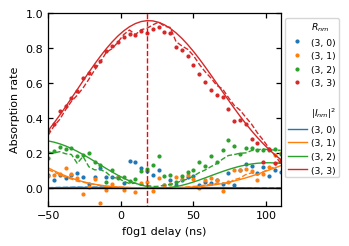

In [9]:
ph3_fo0 = "/2025-08-13/2025-08-13T032400_84bc5ae9-j1_JPA_comm_timing"
ph3_fo1 = "/2025-08-13/2025-08-13T040856_cb5ba4f9-j1_JPA_comm_timing"
ph3_fo2 = "/2025-08-13/2025-08-13T045352_12672ec9-j1_JPA_comm_timing"
ph3_fo3 = "/2025-08-13/2025-08-13T053850_5a9232a6-j1_JPA_comm_timing"

acquisition_30 = SpatiotemporalAnalysis(ctrl_path, ph3_fo0, ctrl_path, result_dict_tx['data_ph3'], result_dict_rx['data_ph0'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_31 = SpatiotemporalAnalysis(ctrl_path, ph3_fo1, ctrl_path, result_dict_tx['data_ph3'], result_dict_rx['data_ph1'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_32 = SpatiotemporalAnalysis(ctrl_path, ph3_fo2, ctrl_path, result_dict_tx['data_ph3'], result_dict_rx['data_ph2'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_33 = SpatiotemporalAnalysis(ctrl_path, ph3_fo3, ctrl_path, result_dict_tx['data_ph3'], result_dict_rx['data_ph3'], num_of_ph_amp, num_of_fogi_timing, f_if)

fig, ax = plt.subplots(1, 1, figsize=(3, 2.5))
acquisition_30.plot_results(ax, label="ph_3 & fogi_0", color="tab:blue", fitting=True, init_fit=True, x_target=18)
acquisition_31.plot_results(ax, label="ph_3 & fogi_1", color="tab:orange", fitting=True, init_fit=True, x_target=18)
acquisition_32.plot_results(ax, label="ph_3 & fogi_2", color="tab:green", fitting=True, init_fit=True, x_target=18)
acquisition_33.plot_results(ax, label="ph_3 & fogi_3", color="tab:red", fitting=True, init_fit=True, x_target=18)

ax.set_ylim(-0.10, 1)
ax.set_xlim(-50, 110)
plt.vlines(18, -10, 100, linestyles='--',colors='red')
custom_legend = [
    Line2D([0], [0], color="none", marker="o", linestyle="None", label="$R_{nm}$"),
    Line2D([0], [0], color="tab:blue", marker="o", linestyle="None",label="(3, 0)"),
    Line2D([0], [0], color="tab:orange", marker="o", linestyle="None",label="(3, 1)"),
    Line2D([0], [0], color="tab:green", marker="o", linestyle="None",label="(3, 2)"),
    Line2D([0], [0], color="tab:red", marker="o", linestyle="None",label="(3, 3)"),
    Line2D([0], [0], color="none", marker="", label=""),
    Line2D([0], [0], color="none", linestyle="-", label="$|I_{nm}|^2$"),
    Line2D([0], [0], color="tab:blue", linestyle="-", label="(3, 0)"),
    Line2D([0], [0], color="tab:orange", linestyle="-", label="(3, 1)"),
    Line2D([0], [0], color="tab:green", linestyle="-", label="(3, 2)"),
    Line2D([0], [0], color="tab:red", linestyle="-", label="(3, 3)"),
]
plt.legend(handles=custom_legend, loc="upper left", bbox_to_anchor=(1., 1),ncol=1,  fontsize="small", 
           handletextpad=0.5, borderpad=0.3 )
plt.hlines(0, -50, 110, "black")
plt.xlabel("f0g1 delay (ns)")
plt.ylabel("Absorption rate")
plt.show()

delay 22.500000000000004
delay 19.800000000000004
delay 21.6
delay 21.6
delay 36.89999999999999
delay 30.6
delay 31.5
delay 21.6


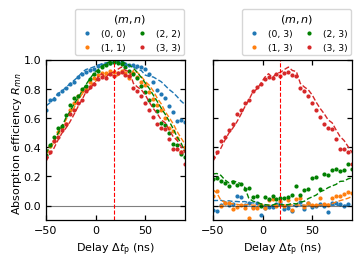

In [10]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

num_of_ph_amp = 1
num_of_fogi_timing = 51
f_if = (9.5-9.38)*1e9

fig, ax = plt.subplots(1, 2, figsize=(3.6, 2.2))
acquisition_00.plot_results(ax[0], label="ph_0 & fogi_0", color="tab:blue", fitting=False, init_fit=True, err_bar=False)
acquisition_11.plot_results(ax[0], label="ph_1 & fogi_1", color="tab:orange", fitting=False, init_fit=True, err_bar=False)
acquisition_22.plot_results(ax[0], label="ph_2 & fogi_2", color="green", fitting=False, init_fit=True, err_bar=False)
acquisition_33.plot_results(ax[0], label="ph_3 & fogi_3", color="tab:red", fitting=False, init_fit=True, err_bar=False)

acquisition_03.plot_results(ax[1], label="ph_0 & fogi_3", color="tab:blue", fitting=False, init_fit=True, err_bar=False)
acquisition_13.plot_results(ax[1], label="ph_1 & fogi_3", color="tab:orange", fitting=False, init_fit=True, err_bar=False)
acquisition_23.plot_results(ax[1], label="ph_2 & fogi_3", color="green", fitting=False, init_fit=True, err_bar=False)
acquisition_33.plot_results(ax[1], label="ph_3 & fogi_3", color="tab:red", fitting=False, init_fit=True, err_bar=False)

custom_legend0 = [
    # Line2D([0], [0], color="none", marker="o", linestyle="None", label="$(m, n)$"),
    Line2D([0], [0], color="tab:blue", marker="o", linestyle="None",label="(0, 0)"),
    Line2D([0], [0], color="tab:orange", marker="o", linestyle="None",label="(1, 1)"),
    Line2D([0], [0], color="green", marker="o", linestyle="None",label="(2, 2)"),
    Line2D([0], [0], color="tab:red", marker="o", linestyle="None",label="(3, 3)"),
]
ax[0].legend(handles=custom_legend0, title=r"$(m, n)$", loc="lower center", bbox_to_anchor=(0.6, 1),ncol=2,  fontsize="small", 
           handletextpad=0.5, borderpad=0.3, columnspacing=0.8 )

custom_legend1 = [
    # Line2D([0], [0], color="none", marker="o", linestyle="None", label="$(m, n)$"),
    Line2D([0], [0], color="tab:blue", marker="o", linestyle="None",label="(0, 3)"),
    Line2D([0], [0], color="tab:orange", marker="o", linestyle="None",label="(1, 3)"),
    Line2D([0], [0], color="green", marker="o", linestyle="None",label="(2, 3)"),
    Line2D([0], [0], color="tab:red", marker="o", linestyle="None",label="(3, 3)"),
]
ax[1].legend(handles=custom_legend1, title=r"$(m, n)$", loc="lower center", bbox_to_anchor=(0.6, 1),ncol=2,  fontsize="small", 
           handletextpad=0.5, borderpad=0.3, columnspacing=0.8 )

ax[0].set_ylim(-0.1, 1)
ax[0].set_xlim(-50, 90)
ax[0].set_xlabel(r"Delay $\Delta t_\mathrm{p}$ (ns)")
ax[1].set_ylim(-0.1, 1)
ax[1].set_xlim(-50, 90)
ax[1].set_xlabel(r"Delay $\Delta t_\mathrm{p}$ (ns)")

fig.text(0.02, 0.55, r"Absorption efficiency $R_{mn}$", va='center', rotation='vertical')
for a in ax:
    a.tick_params(axis="both", direction="in")
    a.axhline(0, color='black', linewidth=0.8, alpha=0.5, linestyle='-')
    a.axvline(18, color='red', linewidth=0.8, linestyle="dashed") 
ax[1].tick_params(labelleft=False) 
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.

plt.subplots_adjust(left=0.12, right=0.97, top=0.93, bottom=0.2, wspace=0.2)
# plt.savefig('Fig3bc.pdf', bbox_inches='tight')
plt.show()

## analysis

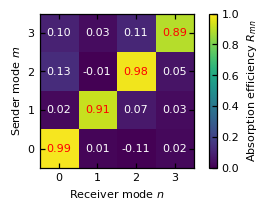

376.9075233025843


In [ ]:
fig, ax = plt.subplots(figsize=(4, 2))
i = 17
data = np.array([[acquisition_30.get_rates()["rates"][i], acquisition_31.get_rates()["rates"][i], acquisition_32.get_rates()["rates"][i], acquisition_33.get_rates()["rates"][i]],
                [acquisition_20.get_rates()["rates"][i], acquisition_21.get_rates()["rates"][i], acquisition_22.get_rates()["rates"][i], acquisition_23.get_rates()["rates"][i]],
                [acquisition_10.get_rates()["rates"][i], acquisition_11.get_rates()["rates"][i], acquisition_12.get_rates()["rates"][i], acquisition_13.get_rates()["rates"][i]],
                [acquisition_00.get_rates()["rates"][i], acquisition_01.get_rates()["rates"][i], acquisition_02.get_rates()["rates"][i], acquisition_03.get_rates()["rates"][i]]])

err = np.array([[acquisition_30.get_rates()["rates_err"][i], acquisition_31.get_rates()["rates_err"][i], acquisition_32.get_rates()["rates_err"][i], acquisition_33.get_rates()["rates_err"][i]],
                [acquisition_20.get_rates()["rates_err"][i], acquisition_21.get_rates()["rates_err"][i], acquisition_22.get_rates()["rates_err"][i], acquisition_23.get_rates()["rates_err"][i]],
                [acquisition_10.get_rates()["rates_err"][i], acquisition_11.get_rates()["rates_err"][i], acquisition_12.get_rates()["rates_err"][i], acquisition_13.get_rates()["rates_err"][i]],
                [acquisition_00.get_rates()["rates_err"][i], acquisition_01.get_rates()["rates_err"][i], acquisition_02.get_rates()["rates_err"][i], acquisition_03.get_rates()["rates_err"][i]]])*0.01

SpatiotemporalAnalysis.plot_absorption_rate_matrix(data, err, ax)


# plt.close()
# plt.imshow(plt.imread("abs_rate.png"))
ax.tick_params(axis="both", direction="in")
ax.tick_params(top=True, bottom=True, left=True, right=True)
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.
# plt.savefig('Fig3d.pdf', bbox_inches='tight')
plt.show()
print(acquisition_00.get_rates()["rates"][i]+acquisition_11.get_rates()["rates"][i]
      +acquisition_22.get_rates()["rates"][i]+acquisition_33.get_rates()["rates"][i])